📊 JOB MARKET ANALYSIS - KEY INSIGHTS

🔧 Checking for skill columns...
   ✅ All skill columns already exist!

🎯 QUESTION 1: Most Demanded Skills

📈 TOP 10 MOST DEMANDED SKILLS:
   1. R                    -  97.9% of jobs (98 jobs)
   2. Python               -  30.9% of jobs (31 jobs)
   3. Power BI             -  30.6% of jobs (31 jobs)
   4. SQL                  -  29.0% of jobs (29 jobs)
   5. Machine Learning     -  24.5% of jobs (24 jobs)
   6. Excel                -  22.3% of jobs (22 jobs)
   7. Tableau              -  22.1% of jobs (22 jobs)
   8. Visualization        -  22.1% of jobs (22 jobs)
   9. DAX                  -  21.8% of jobs (22 jobs)
   10. JavaScript           -  21.0% of jobs (21 jobs)
   11. AWS                  -  20.5% of jobs (20 jobs)
   12. TensorFlow           -  19.9% of jobs (20 jobs)
   13. Azure                -  19.7% of jobs (20 jobs)


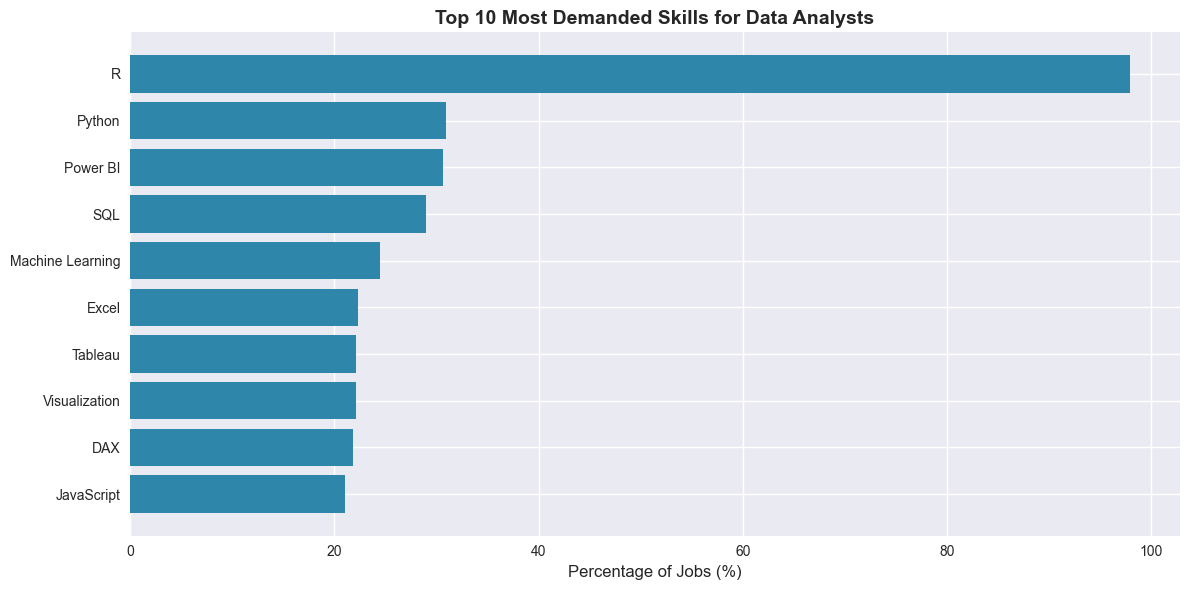


   📁 Chart saved to: output/top_skills.png

💰 QUESTION 2: Salary Trends

📊 OVERALL SALARY STATISTICS:
   Average Salary: ₹985,631
   Median Salary:  ₹994,462
   Min Salary:     ₹302,719
   Max Salary:     ₹1,999,751

📊 SALARY BY EXPERIENCE LEVEL:
                       mean     median  count
experience_level                             
Lead              1016786.0  1017416.0     31
Mid                990721.0  1018558.0    157
Senior             976828.0   985101.0     84
Entry              975770.0   984359.0    104


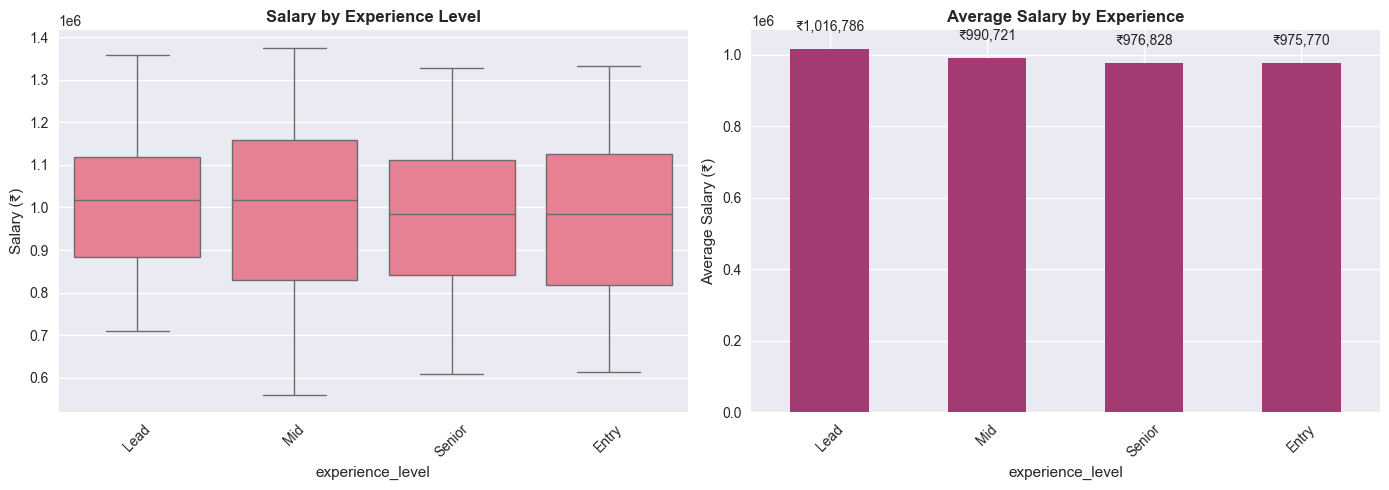


   📁 Chart saved to: output/salary_trends.png

🏠 QUESTION 3: Remote vs Onsite Jobs

📊 JOB TYPE DISTRIBUTION:
   Remote     - 128 jobs (34.0%)
   Hybrid     - 125 jobs (33.2%)
   Onsite     - 123 jobs (32.7%)

   🌟 Total Remote/Hybrid: 67.2%


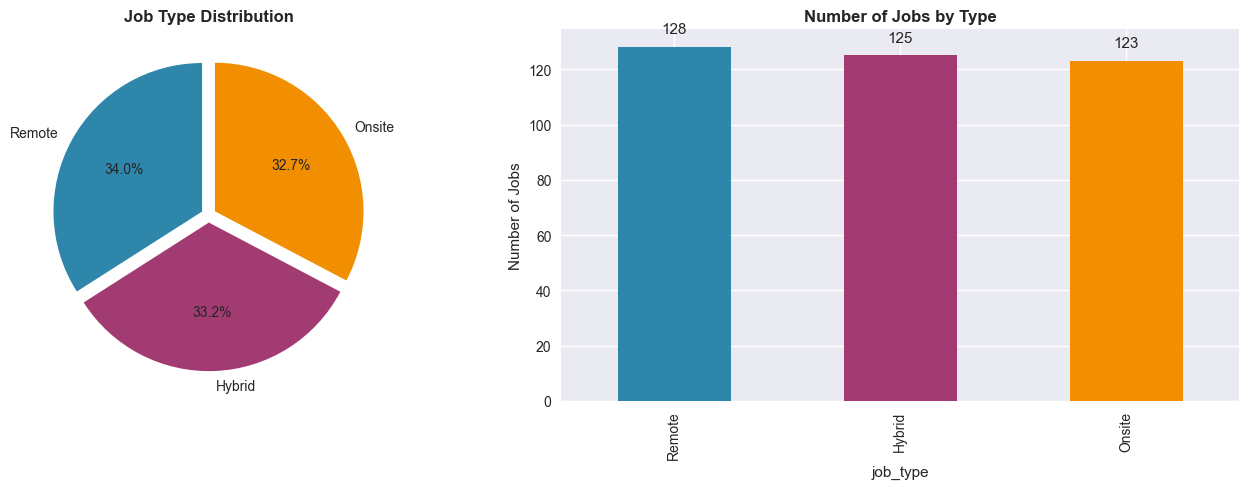


   📁 Chart saved to: output/remote_vs_onsite.png

🏙️ QUESTION 4: Hiring Trends by City

📊 TOP CITIES BY JOB COUNT:
   1. Bangalore    - 107 jobs | Avg Salary: ₹985,543
   2. Hyderabad    -  78 jobs | Avg Salary: ₹1,004,322
   3. Mumbai       -  65 jobs | Avg Salary: ₹949,284
   4. Delhi        -  49 jobs | Avg Salary: ₹974,955
   5. Pune         -  37 jobs | Avg Salary: ₹1,011,314
   6. Chennai      -  19 jobs | Avg Salary: ₹957,836
   7. Gurgaon      -  14 jobs | Avg Salary: ₹1,027,682
   8. Kolkata      -   7 jobs | Avg Salary: ₹1,046,499


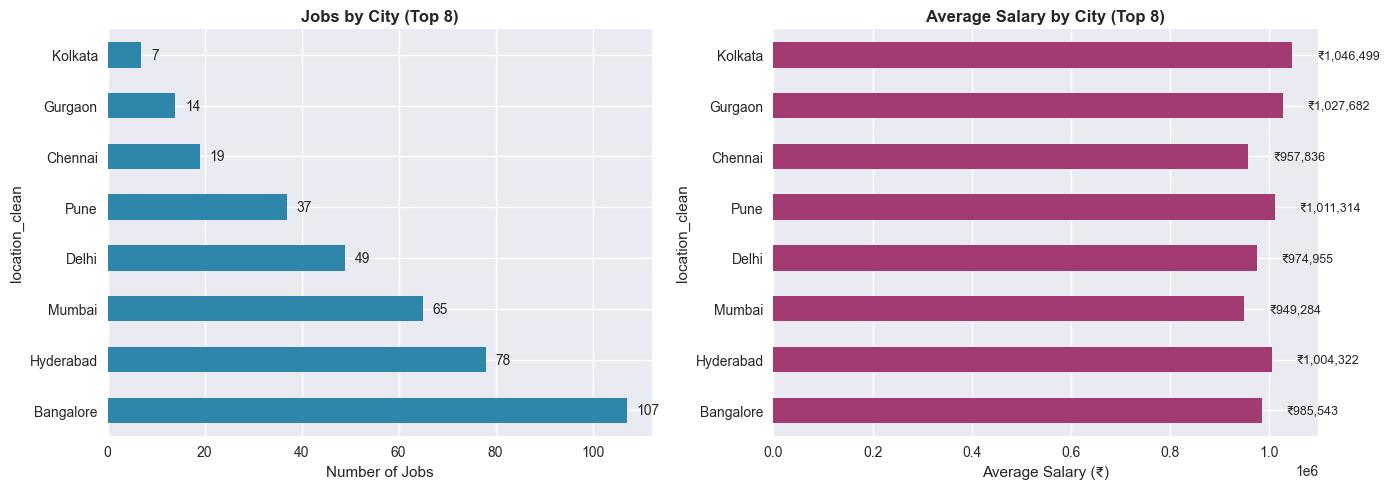


   📁 Chart saved to: output/city_trends.png

📋 ANALYSIS SUMMARY

✅ Total Jobs Analyzed: 376
✅ Top Skill: R (97.9% of jobs)
✅ Average Salary: ₹985,631
✅ Remote/Hybrid Jobs: 67.2%
✅ Top City: Bangalore (107 jobs)

📁 All charts saved in 'output/' folder
✅ Analysis complete!



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load cleaned data
df = pd.read_csv('../data/cleaned/data_analyst_jobs.csv')

print("="*70)
print("📊 JOB MARKET ANALYSIS - KEY INSIGHTS")
print("="*70)

# ─────────────────────────────────────────────────────────────
# FIX: Create skill columns if they don't exist
# ─────────────────────────────────────────────────────────────
print("\n🔧 Checking for skill columns...")

# List of skill columns to check
skill_cols = ['Python', 'SQL', 'Excel', 'Power BI', 'Tableau', 'Machine Learning',
              'TensorFlow', 'AWS', 'Azure', 'R', 'JavaScript', 'DAX', 'Visualization']

# Check if skill columns exist
missing_cols = [col for col in skill_cols if col not in df.columns]

if missing_cols:
    print(f"   ⚠️ Skill columns missing: {missing_cols}")
    print("   ➡️ Creating skill columns from 'required_skills' column...")
    
    # Make sure required_skills column exists
    if 'required_skills' not in df.columns:
        print("   ❌ 'required_skills' column not found!")
        print("   Available columns:", df.columns.tolist())
        raise ValueError("Dataset doesn't have 'required_skills' column")
    
    # Create skill columns
    for skill in skill_cols:
        df[skill] = df['required_skills'].str.contains(skill, case=False, na=False).astype(int)
    
    print("   ✅ Created skill columns!")
else:
    print("   ✅ All skill columns already exist!")

# ─────────────────────────────────────────────────────────────
# ANALYSIS 1: Most Demanded Skills
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("🎯 QUESTION 1: Most Demanded Skills")
print("="*70)

# Count skills
skill_counts = df[skill_cols].sum().sort_values(ascending=False)
skill_percent = (skill_counts / len(df) * 100).round(1)

print("\n📈 TOP 10 MOST DEMANDED SKILLS:")
for i, (skill, count) in enumerate(zip(skill_percent.index, skill_percent.values), 1):
    print(f"   {i}. {skill:20s} - {count:5.1f}% of jobs ({count:.0f} jobs)")

# Visualize
try:
    fig, ax = plt.subplots(figsize=(12, 6))
    top_skills = skill_percent.head(10)
    ax.barh(top_skills.index[::-1], top_skills.values[::-1], color='#2E86AB')
    ax.set_xlabel('Percentage of Jobs (%)', fontsize=12)
    ax.set_title('Top 10 Most Demanded Skills for Data Analysts', fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../output/top_skills.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n   📁 Chart saved to: output/top_skills.png")
except Exception as e:
    print(f"\n   ⚠️ Could not create chart: {e}")

# ─────────────────────────────────────────────────────────────
# ANALYSIS 2: Salary Trends
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("💰 QUESTION 2: Salary Trends")
print("="*70)

print("\n📊 OVERALL SALARY STATISTICS:")
print(f"   Average Salary: ₹{df['salary_avg'].mean():,.0f}")
print(f"   Median Salary:  ₹{df['salary_avg'].median():,.0f}")
print(f"   Min Salary:     ₹{df['salary_min'].min():,.0f}")
print(f"   Max Salary:     ₹{df['salary_max'].max():,.0f}")

print("\n📊 SALARY BY EXPERIENCE LEVEL:")
salary_by_level = df.groupby('experience_level')['salary_avg'].agg(['mean', 'median', 'count']).round(0)
salary_by_level = salary_by_level.sort_values('mean', ascending=False)
print(salary_by_level.to_string())

# Visualize
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Salary by experience
    ax1 = axes[0]
    level_order = salary_by_level.index
    sns.boxplot(data=df, x='experience_level', y='salary_avg', ax=ax1, order=level_order)
    ax1.set_title('Salary by Experience Level', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Salary (₹)')
    ax1.tick_params(axis='x', rotation=45)

    # Average salary bar chart
    ax2 = axes[1]
    salary_by_level['mean'].plot(kind='bar', ax=ax2, color='#A23B72')
    ax2.set_title('Average Salary by Experience', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Salary (₹)')
    ax2.tick_params(axis='x', rotation=45)
    for i, v in enumerate(salary_by_level['mean']):
        ax2.text(i, v + 50000, f'₹{v:,.0f}', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('output/salary_trends.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n   📁 Chart saved to: output/salary_trends.png")
except Exception as e:
    print(f"\n   ⚠️ Could not create chart: {e}")

# ─────────────────────────────────────────────────────────────
# ANALYSIS 3: Remote vs Onsite Jobs
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("🏠 QUESTION 3: Remote vs Onsite Jobs")
print("="*70)

job_type_counts = df['job_type'].value_counts()
job_type_percent = (job_type_counts / len(df) * 100).round(1)

print("\n📊 JOB TYPE DISTRIBUTION:")
for job_type, count in job_type_counts.items():
    percent = job_type_percent[job_type]
    print(f"   {job_type:10s} - {count:3d} jobs ({percent:.1f}%)")

remote_percentage = job_type_percent.get('Remote', 0) + job_type_percent.get('Hybrid', 0)
print(f"\n   🌟 Total Remote/Hybrid: {remote_percentage:.1f}%")

# Visualize
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Pie chart
    ax1 = axes[0]
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    ax1.pie(job_type_counts.values, labels=job_type_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors, explode=(0.05, 0.05, 0.05))
    ax1.set_title('Job Type Distribution', fontsize=12, fontweight='bold')

    # Bar chart
    ax2 = axes[1]
    job_type_counts.plot(kind='bar', ax=ax2, color=colors)
    ax2.set_title('Number of Jobs by Type', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Jobs')
    for i, v in enumerate(job_type_counts.values):
        ax2.text(i, v + 5, f'{v}', ha='center', fontsize=11)

    plt.tight_layout()
    plt.savefig('output/remote_vs_onsite.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n   📁 Chart saved to: output/remote_vs_onsite.png")
except Exception as e:
    print(f"\n   ⚠️ Could not create chart: {e}")

# ─────────────────────────────────────────────────────────────
# ANALYSIS 4: Hiring Trends by City
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("🏙️ QUESTION 4: Hiring Trends by City")
print("="*70)

city_stats = df.groupby('location_clean').agg({
    'job_id': 'count',
    'salary_avg': ['mean', 'median'],
    'company': 'nunique'
}).round(0)

city_stats.columns = ['job_count', 'avg_salary', 'median_salary', 'company_count']
city_stats = city_stats.sort_values('job_count', ascending=False)

print("\n📊 TOP CITIES BY JOB COUNT:")
for i, (city, row) in enumerate(city_stats.iterrows(), 1):
    print(f"   {i}. {city:12s} - {int(row['job_count']):3d} jobs | Avg Salary: ₹{int(row['avg_salary']):,}")

# Visualize
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Job count by city
    ax1 = axes[0]
    top_cities = city_stats.head(8)
    top_cities['job_count'].plot(kind='barh', ax=ax1, color='#2E86AB')
    ax1.set_xlabel('Number of Jobs')
    ax1.set_title('Jobs by City (Top 8)', fontsize=12, fontweight='bold')
    for i, v in enumerate(top_cities['job_count']):
        ax1.text(v + 2, i, f'{int(v)}', va='center', fontsize=10)

    # Average salary by city
    ax2 = axes[1]
    top_cities['avg_salary'].plot(kind='barh', ax=ax2, color='#A23B72')
    ax2.set_xlabel('Average Salary (₹)')
    ax2.set_title('Average Salary by City (Top 8)', fontsize=12, fontweight='bold')
    for i, v in enumerate(top_cities['avg_salary']):
        ax2.text(v + 50000, i, f'₹{int(v):,}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('output/city_trends.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n   📁 Chart saved to: output/city_trends.png")
except Exception as e:
    print(f"\n   ⚠️ Could not create chart: {e}")

# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("📋 ANALYSIS SUMMARY")
print("="*70)
print(f"""
✅ Total Jobs Analyzed: {len(df)}
✅ Top Skill: {skill_percent.index[0]} ({skill_percent.values[0]:.1f}% of jobs)
✅ Average Salary: ₹{df['salary_avg'].mean():,.0f}
✅ Remote/Hybrid Jobs: {remote_percentage:.1f}%
✅ Top City: {city_stats.index[0]} ({int(city_stats['job_count'].iloc[0])} jobs)

📁 All charts saved in 'output/' folder
✅ Analysis complete!
""")